<!-- CODEx Chinese cell explanation: start -->
### Cell 01 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 01 — Computational step 01

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [1]:

import math
import os
import sqlite3
import subprocess
import textwrap
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
from scipy.stats import qmc

plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.prop_cycle": cycler(color=["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"]),
    "grid.alpha": 0.20,
    "grid.linestyle": "--",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
INPUT_DIR = PROJECT_ROOT / "input"
OUTPUT_DIR = PROJECT_ROOT / "outputs_step1"
IDF_DIR = OUTPUT_DIR / "generated_idf"
RUN_DIR = OUTPUT_DIR / "runs"
FIG_DIR = OUTPUT_DIR / "figures"
for p in [DATA_DIR, INPUT_DIR, OUTPUT_DIR, IDF_DIR, RUN_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # Usually only the sample size needs to be changed.
    "n_samples": int(os.environ.get("EUI_N_SAMPLES", "2000")),
    "random_seed": 42,
    # EnergyPlus 25.2.0 path (Windows example).
    "energyplus_exe": r"C:/EnergyPlusV25-2-0/energyplus.exe",
    "expandobjects_exe": r"C:\EnergyPlusV25-2-0\ExpandObjects.exe",
    # Beijing weather file path.
    "weather_epw": str(INPUT_DIR / "Beijing.epw"),
    # Whether to actually run EnergyPlus simulations.
    "run_energyplus": os.environ.get("EUI_RUN_ENERGYPLUS", "0") == "1",
    "timeout_seconds": int(os.environ.get("EUI_TIMEOUT_SECONDS", "900")),
    "clean_idf_dir": os.environ.get("EUI_CLEAN_IDF_DIR", "0") == "1",
    "clean_run_dir": os.environ.get("EUI_CLEAN_RUN_DIR", "0") == "1",
    # Engineering post-processing parameters.
    "dhw_cold_water_temp_c": 15.0,
    "dhw_density_kg_m3": 1000.0,
    "water_cp_kj_kgk": 4.186,
    "fan_delta_p_pa": 600.0,
    # Controls for feasible area ratios.
    "min_usable_ratio": 0.55,
    "max_usable_ratio": 0.95,
}

display_config = dict(CONFIG)
display_config["weather_epw"] = "input/Beijing.epw"
display_config["energyplus_exe"] = "C:/EnergyPlusV25-2-0/energyplus.exe"
display_config["expandobjects_exe"] = "C:/EnergyPlusV25-2-0/ExpandObjects.exe"
print(display_config)

{'n_samples': 500, 'random_seed': 42, 'energyplus_exe': 'C:/EnergyPlusV25-2-0/energyplus.exe', 'expandobjects_exe': 'C:/EnergyPlusV25-2-0/ExpandObjects.exe', 'weather_epw': 'input/Beijing.epw', 'run_energyplus': False, 'timeout_seconds': 900, 'clean_idf_dir': False, 'clean_run_dir': False, 'dhw_cold_water_temp_c': 15.0, 'dhw_density_kg_m3': 1000.0, 'water_cp_kj_kgk': 4.186, 'fan_delta_p_pa': 600.0, 'min_usable_ratio': 0.55, 'max_usable_ratio': 0.95}


<!-- CODEx Chinese cell explanation: start -->
### Cell 02 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 02 — Computational step 02

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [2]:
from pathlib import Path
import os, sys

print("Current Python executable: ", sys.executable)
print("Current working directory: <project root>")

ep = Path(CONFIG["energyplus_exe"])
wth = Path(CONFIG["weather_epw"])

print("\n[EnergyPlus path]")
print("Original value: ", CONFIG["energyplus_exe"])
print("Resolved path: ", ep)
print("Exists: ", ep.exists())
print("Is file: ", ep.is_file())

print("\n[Weather file path]")
print("Original value: input/Beijing.epw")
print("Resolved path: <project root>/input/Beijing.epw")
print("Exists: ", wth.exists())
print("Is file: ", wth.is_file())

print("\n[Files under the input directory]")
input_dir = Path.cwd() / "input"
print("Input directory exists: ", input_dir.exists())
if input_dir.exists():
    for f in input_dir.iterdir():
        print(" -", f.name)

Current Python executable:  D:\python311\python.exe
Current working directory: <project root>

[EnergyPlus path]
Original value:  C:/EnergyPlusV25-2-0/energyplus.exe
Resolved path:  C:\EnergyPlusV25-2-0\energyplus.exe
Exists:  True
Is file:  True

[Weather file path]
Original value: input/Beijing.epw
Resolved path: <project root>/input/Beijing.epw
Exists:  True
Is file:  True

[Files under the input directory]
Input directory exists:  True
 - Beijing.epw


<!-- CODEx Chinese cell explanation: start -->
### Cell 03 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 03 — Computational step 03

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [3]:
# ---------- 1) Parameter-space definition ----------
# Note: some variables in the manuscript are naturally coupled or redundant:
# - building_length / building_width / aspect_ratio
# - insulation thickness / wall U-value
# - roof insulation thickness / roof U-value
# The fields remain compatible with the manuscript, but sampling and generation use independent variables, derived variables, and constraint checks.

FEATURES = [
    {"name": "insul_thick", "kind": "float", "min": 0.05, "max": 0.12, "default": 0.08},
    {"name": "wwr", "kind": "float", "min": 0.25, "max": 0.60, "default": 0.40},
    {"name": "wall_thick", "kind": "float", "min": 0.20, "max": 0.30, "default": 0.24},
    {"name": "u_win_n", "kind": "float", "min": 0.8, "max": 2.0, "default": 1.4},
    {"name": "u_win_s", "kind": "float", "min": 0.8, "max": 2.0, "default": 1.4},
    {"name": "u_win_e", "kind": "float", "min": 0.8, "max": 2.0, "default": 1.4},
    {"name": "u_win_w", "kind": "float", "min": 0.8, "max": 2.0, "default": 1.4},
    {"name": "u_wall", "kind": "float", "min": 0.25, "max": 0.80, "default": 0.45},
    {"name": "u_roof", "kind": "float", "min": 0.20, "max": 0.45, "default": 0.30},
    {"name": "u_ground", "kind": "float", "min": 0.15, "max": 0.40, "default": 0.35},
    {"name": "shgc_n", "kind": "float", "min": 0.20, "max": 0.65, "default": 0.40},
    {"name": "shgc_s", "kind": "float", "min": 0.20, "max": 0.45, "default": 0.35},
    {"name": "shgc_e", "kind": "float", "min": 0.20, "max": 0.65, "default": 0.40},
    {"name": "shgc_w", "kind": "float", "min": 0.20, "max": 0.65, "default": 0.40},
    {"name": "window_type_id", "kind": "int", "min": 1, "max": 3, "default": 2},
    {"name": "roof_insul_thick", "kind": "float", "min": 0.08, "max": 0.15, "default": 0.12},
    {"name": "floor_num", "kind": "int", "min": 6, "max": 20, "default": 10},
    {"name": "public_area", "kind": "float", "min": 80, "max": 150, "default": 110},
    {"name": "room_area", "kind": "float", "min": 22, "max": 30, "default": 26},
    {"name": "room_count", "kind": "int", "min": 36, "max": 240, "default": 120},
    {"name": "building_length", "kind": "float", "min": 35, "max": 50, "default": 42},
    {"name": "building_width", "kind": "float", "min": 12, "max": 18, "default": 15},
    {"name": "aspect_ratio", "kind": "float", "min": 2.0, "max": 3.0, "default": 2.5},
    {"name": "floor_height", "kind": "float", "min": 2.8, "max": 3.3, "default": 3.0},
    {"name": "orientation_deg", "kind": "float", "min": 0, "max": 90, "default": 0},
    {"name": "equip_power", "kind": "float", "min": 2.5, "max": 4.0, "default": 3.2},
    {"name": "dhw_per_person", "kind": "float", "min": 0.06, "max": 0.20, "default": 0.12},
    {"name": "occupancy_density", "kind": "float", "min": 0.08, "max": 0.25, "default": 0.12},
    {"name": "light_power", "kind": "float", "min": 4.0, "max": 7.0, "default": 5.5},
    {"name": "cool_set", "kind": "float", "min": 24, "max": 26, "default": 25},
    {"name": "heat_set", "kind": "float", "min": 19, "max": 22, "default": 20},
    {"name": "dhw_temp", "kind": "float", "min": 45, "max": 55, "default": 50},
    {"name": "cop_cooling", "kind": "float", "min": 3.0, "max": 5.0, "default": 4.0},
    {"name": "cop_heating", "kind": "float", "min": 2.2, "max": 4.2, "default": 3.0},
    {"name": "boiler_eff", "kind": "float", "min": 0.82, "max": 0.95, "default": 0.90},
    {"name": "fan_eff", "kind": "float", "min": 0.55, "max": 0.70, "default": 0.65},
    {"name": "fresh_air_ach", "kind": "float", "min": 0.5, "max": 1.2, "default": 0.8},
    {"name": "operation_hours", "kind": "float", "min": 2000, "max": 3000, "default": 2600},
]

feature_df = pd.DataFrame(FEATURES)
feature_df.head(38)

,name,kind,min,max,default
0,insul_thick,float,0.05,0.12,0.08
1,wwr,float,0.25,0.60,0.40
2,wall_thick,float,0.20,0.30,0.24
3,u_win_n,float,0.80,2.00,1.40
4,u_win_s,float,0.80,2.00,1.40
5,u_win_e,float,0.80,2.00,1.40
6,u_win_w,float,0.80,2.00,1.40
7,u_wall,float,0.25,0.80,0.45
8,u_roof,float,0.20,0.45,0.30
9,u_ground,float,0.15,0.40,0.35


<!-- CODEx Chinese cell explanation: start -->
### Cell 04 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 04 — Computational step 04

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [4]:
# ---------- 2) LHS sampling and constraint correction ----------

def lhs_sample(feature_table: pd.DataFrame, n_samples: int, seed: int = 42) -> pd.DataFrame:
    active = feature_table.reset_index(drop=True)
    sampler = qmc.LatinHypercube(d=len(active), seed=seed)
    unit = sampler.random(n=n_samples)

    out = {}
    for i, row in active.iterrows():
        lo, hi = float(row["min"]), float(row["max"])
        values = lo + (hi - lo) * unit[:, i]
        if row["kind"] == "int":
            values = np.rint(values).astype(int)
            values = np.clip(values, int(lo), int(hi))
        out[row["name"]] = values

    df = pd.DataFrame(out)
    df["sample_id"] = [f"sample_{i:04d}" for i in range(1, len(df) + 1)]
    return df


def resolve_dependencies(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Length, width, and aspect ratio: length plus aspect ratio control the geometry; width is derived to avoid inconsistent inputs.
    df["building_width"] = (df["building_length"] / df["aspect_ratio"]).clip(12, 18)

    # Building geometry metrics.
    df["gross_floor_area_m2"] = df["building_length"] * df["building_width"] * df["floor_num"]
    df["footprint_area_m2"] = df["building_length"] * df["building_width"]
    df["building_height_m"] = df["floor_num"] * df["floor_height"]
    df["building_volume_m3"] = df["gross_floor_area_m2"] * df["floor_height"]

    # Functional-area check: guest-room area plus public area should not exceed the gross floor area unrealistically.
    df["guestroom_total_area_m2"] = df["room_area"] * df["room_count"]
    df["usable_area_m2"] = df["guestroom_total_area_m2"] + df["public_area"]
    df["usable_area_ratio"] = df["usable_area_m2"] / df["gross_floor_area_m2"]
    df["geometry_feasible"] = df["usable_area_ratio"].between(CONFIG["min_usable_ratio"], CONFIG["max_usable_ratio"])

    # Occupancy estimate: use the more conservative value from room-based and area-density estimates.
    guest_based_people = df["room_count"] * 1.6
    density_based_people = df["gross_floor_area_m2"] * df["occupancy_density"]
    df["estimated_people"] = np.maximum(1.0, np.minimum(guest_based_people, density_based_people))

    # Convert annual operating hours into average daily operating hours for schedules.
    df["daily_operation_hours"] = (df["operation_hours"] / 365.0).clip(4, 24)
    df["schedule_on_fraction"] = (df["daily_operation_hours"] / 24.0).clip(0.15, 1.0)

    # Simplified envelope thermal resistance: U-values control the model; thickness variables are retained in the dataset but do not double-control construction performance.
    # Approximation used here: R_layer ~= 1/U - R_films; small values are clipped to avoid negative resistance.
    df["wall_R_m2K_W"] = (1.0 / df["u_wall"] - 0.17).clip(0.15, None)
    df["roof_R_m2K_W"] = (1.0 / df["u_roof"] - 0.14).clip(0.15, None)
    df["floor_R_m2K_W"] = (1.0 / df["u_ground"] - 0.17).clip(0.15, None)

    # Prototype visible transmittance is mapped from window_type_id.
    vt_map = {1: 0.55, 2: 0.65, 3: 0.75}
    df["glass_vt"] = df["window_type_id"].map(vt_map).fillna(0.65)

    return df

samples_raw = lhs_sample(feature_df, CONFIG["n_samples"], CONFIG["random_seed"])
samples_raw["source_lhs_index"] = np.arange(len(samples_raw))
samples_all = resolve_dependencies(samples_raw)
samples = samples_all.loc[samples_all["geometry_feasible"]].copy().reset_index(drop=True)

print(f"Initial number of samples: {len(samples_raw)}")
print(f"Samples retained after geometry/function filters: {len(samples)}")
samples.head(30)

Initial number of samples: 500
Samples retained after geometry/function filters: 121


,insul_thick,wwr,wall_thick,u_win_n,u_win_s,u_win_e,u_win_w,u_wall,u_roof,u_ground,...,usable_area_m2,usable_area_ratio,geometry_feasible,estimated_people,daily_operation_hours,schedule_on_fraction,wall_R_m2K_W,roof_R_m2K_W,floor_R_m2K_W,glass_vt
0,0.115775,0.327100,0.249048,1.760673,1.780563,1.676894,1.794598,0.415385,0.410458,0.180292,...,5437.304057,0.747814,True,304.0,6.296459,0.262352,2.237404,2.296304,5.376555,0.65
1,0.103531,0.328326,0.238772,1.149394,1.676081,1.242569,1.546561,0.454815,0.268266,0.205608,...,5392.207624,0.639134,True,324.8,6.996353,0.291515,2.028695,3.587639,4.693633,0.75
2,0.119740,0.490476,0.222323,1.266465,1.581760,1.608465,1.394053,0.784141,0.377884,0.212816,...,4846.671947,0.638933,True,307.2,5.983787,0.249324,1.105280,2.506317,4.528889,0.55
3,0.059968,0.386784,0.235043,1.364492,0.920130,1.264992,0.892184,0.703095,0.349692,0.297914,...,4930.754097,0.818908,True,288.0,7.952166,0.331340,1.252282,2.719660,3.186669,0.55
4,0.097803,0.320045,0.206844,1.065250,1.787897,1.330432,1.628677,0.421654,0.322941,0.222075,...,6182.533265,0.693071,True,334.4,5.875196,0.244800,2.201615,2.956543,4.332989,0.65
5,0.095586,0.444151,0.296598,1.281898,1.264340,1.010807,1.836402,0.651680,0.273505,0.349222,...,4626.492934,0.551339,True,318.4,7.531290,0.313804,1.364495,3.516234,2.693508,0.65
6,0.054433,0.370509,0.256303,1.290155,1.899555,1.261989,1.414617,0.613454,0.270075,0.342830,...,5376.719168,0.578851,True,326.4,7.440471,0.310020,1.460114,3.562677,2.746900,0.75
7,0.070054,0.293412,0.289116,0.949965,1.169570,1.498890,1.713151,0.301251,0.202953,0.298055,...,4893.792169,0.833379,True,264.0,6.008892,0.250371,3.149488,4.787250,3.185084,0.65
8,0.104194,0.406811,0.240404,1.359313,1.824628,1.793269,1.032069,0.683892,0.247952,0.250077,...,6074.438729,0.574090,True,344.0,7.855675,0.327320,1.292220,3.893047,3.828767,0.55
9,0.084506,0.405926,0.279351,1.673213,1.035344,1.906669,0.862934,0.423231,0.209255,0.310735,...,5386.796026,0.711588,True,296.0,7.155890,0.298162,2.192778,4.638865,3.048175,0.65


<!-- CODEx Chinese cell explanation: start -->
### Cell 05 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 05 — Computational step 05

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

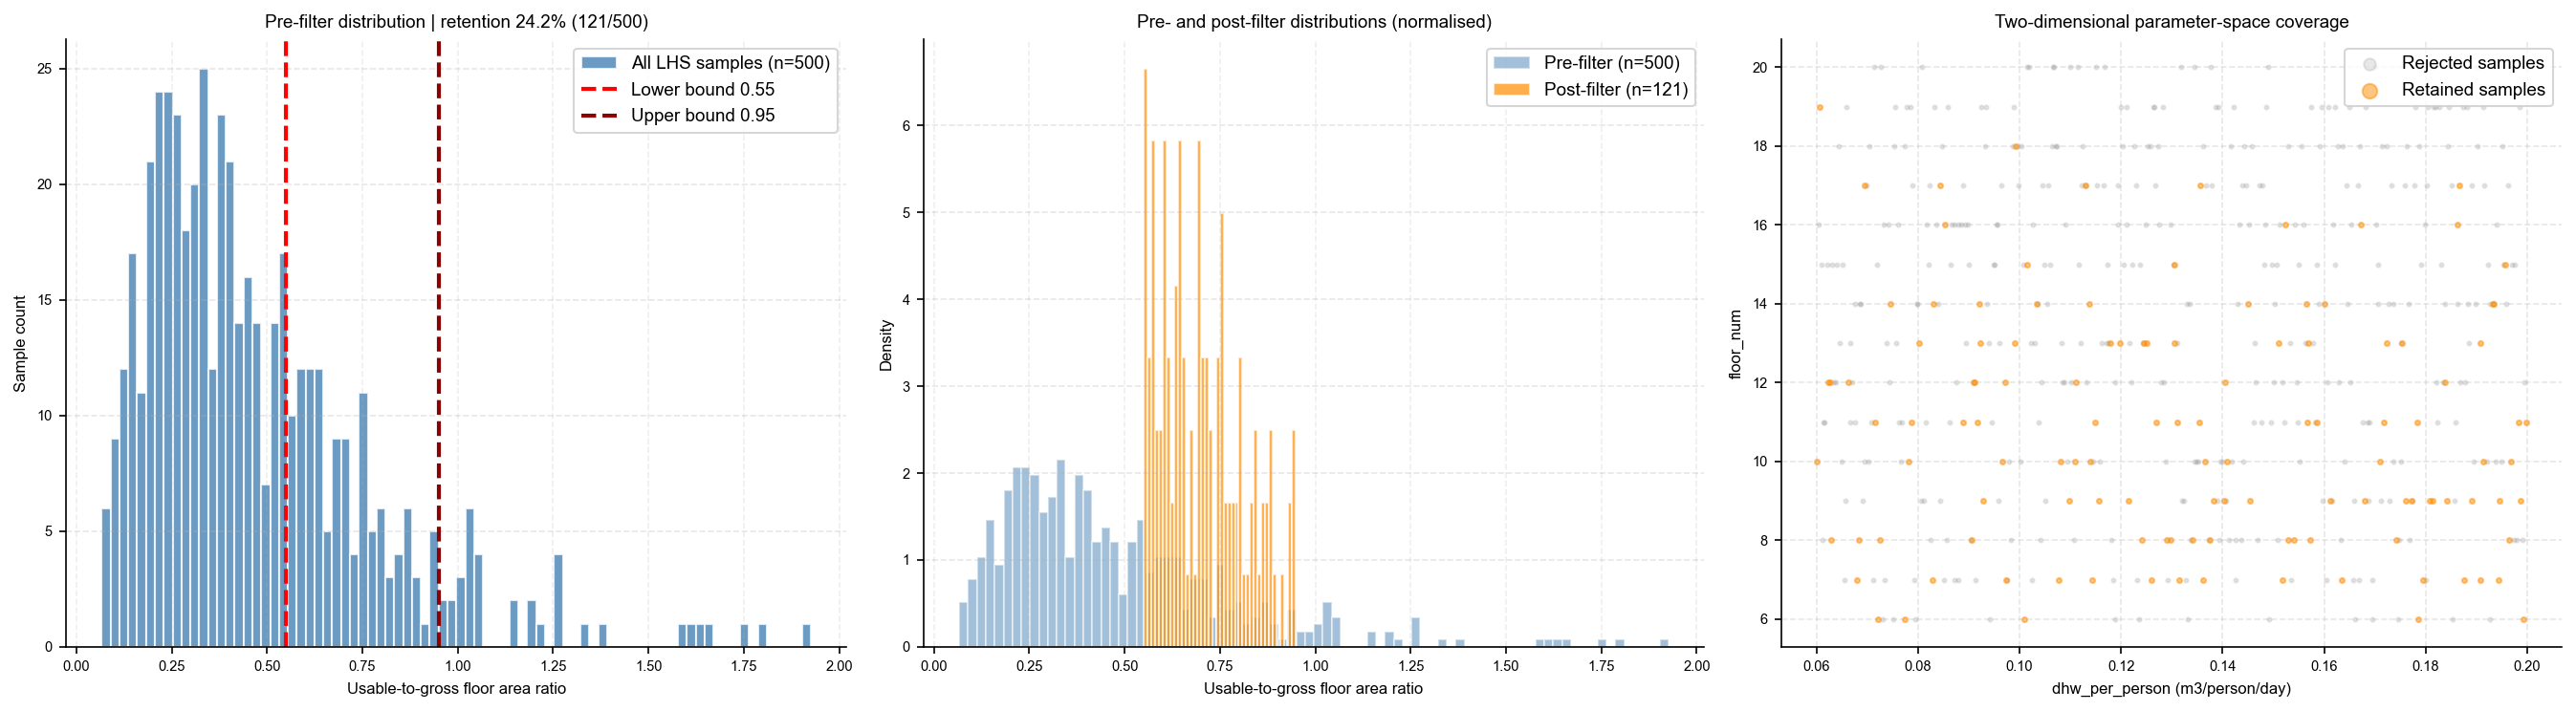

FEASIBILITY SCREENING ANALYSIS
Pre-filterSample count / Pre-filter samples:  500
Post-filterSample count / Post-filter samples: 121
Rejection rate: 75.8%
Pre-filter usable ratio: mean=0.470, std=0.298, min=0.066, max=1.926
Post-filter usable ratio: mean=0.702, std=0.109, min=0.551, max=0.948
Two-sample KS test for usable ratio: D=0.6880, p=3.079e-45

Top 10 variables with the largest distribution shifts:


,feature,pre_mean,post_mean,mean_shift_pct,pre_std,post_std,ks_statistic,ks_p_value,jensen_shannon_distance
19,room_count,138.0100,182.3471,32.1260,58.9403,38.8655,0.3707,0.0000,0.4857
16,floor_num,13.0000,10.7851,-17.0375,4.0641,3.0828,0.2783,0.0000,0.3155
20,building_length,42.4998,41.4616,-2.4428,4.3334,4.2149,0.1482,0.0245,0.3208
21,building_width,16.4511,16.0177,-2.6341,1.7140,1.8107,0.1415,0.0361,0.2412
32,cop_cooling,4.0000,4.1374,3.4354,0.5780,0.5766,0.1295,0.0688,0.2204
7,u_wall,0.5250,0.5484,4.4528,0.1589,0.1517,0.1082,0.1875,0.2233
23,floor_height,3.0500,3.0354,-0.4777,0.1445,0.1329,0.0971,0.2943,0.2588
17,public_area,114.9994,112.7840,-1.9265,20.2318,19.9010,0.0922,0.3541,0.2121
27,occupancy_density,0.1650,0.1582,-4.1135,0.0491,0.0487,0.0908,0.3717,0.2238
22,aspect_ratio,2.5000,2.5361,1.4445,0.2890,0.2997,0.0889,0.3970,0.2539



Variable-level distribution-shift table saved: outputs_step1/feasibility_screening_variable_distribution_shift.csv


In [5]:
# ============================================================
# [IMPROVEMENT P0-2] Feasibility Screening Distribution Analysis
# Quantifies pre/post-filter shifts and visualises retained coverage.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import jensenshannon
from scipy.stats import ks_2samp

rng = np.random.default_rng(CONFIG["random_seed"])

# Use the resolved full sample table so retained/rejected samples are tracked
# by the original LHS row rather than by a reset index.
all_resolved = samples_all.copy()
raw_ratio = all_resolved["usable_area_ratio"].copy()
retained_mask = all_resolved["geometry_feasible"].to_numpy()
filtered_ratio = all_resolved.loc[retained_mask, "usable_area_ratio"].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

# Panel 1: Raw ratio histogram with filter bounds.
ax = axes[0]
ax.hist(raw_ratio, bins=80, color='steelblue', edgecolor='white', alpha=0.8,
        label=f'All LHS samples (n={len(raw_ratio):,})')
ax.axvline(CONFIG["min_usable_ratio"], color='red', linestyle='--', linewidth=2,
           label=f'Lower bound {CONFIG["min_usable_ratio"]}')
ax.axvline(CONFIG["max_usable_ratio"], color='darkred', linestyle='--', linewidth=2,
           label=f'Upper bound {CONFIG["max_usable_ratio"]}')
retention = len(filtered_ratio) / len(raw_ratio) * 100
ax.set_xlabel('Usable-to-gross floor area ratio')
ax.set_ylabel('Sample count')
ax.set_title(f'Pre-filter distribution | retention {retention:.1f}% ({len(filtered_ratio):,}/{len(raw_ratio):,})')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel 2: Pre vs post density comparison.
ax = axes[1]
ax.hist(raw_ratio, bins=80, color='steelblue', edgecolor='white', alpha=0.5,
        density=True, label=f'Pre-filter (n={len(raw_ratio):,})')
ax.hist(filtered_ratio, bins=40, color='darkorange', edgecolor='white', alpha=0.7,
        density=True, label=f'Post-filter (n={len(filtered_ratio):,})')
ax.set_xlabel('Usable-to-gross floor area ratio')
ax.set_ylabel('Density')
ax.set_title('Pre- and post-filter distributions (normalised)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Panel 3: 2D parameter coverage check using true retained/rejected masks.
ax = axes[2]
rejected_index = np.flatnonzero(~retained_mask)
retained_index = np.flatnonzero(retained_mask)
rej_show = rng.choice(rejected_index, size=min(2500, len(rejected_index)), replace=False)
ret_show = rng.choice(retained_index, size=min(2500, len(retained_index)), replace=False)
ax.scatter(all_resolved.iloc[rej_show]['dhw_per_person'],
           all_resolved.iloc[rej_show]['floor_num'],
           c='grey', s=4, alpha=0.18, label='Rejected samples')
ax.scatter(all_resolved.iloc[ret_show]['dhw_per_person'],
           all_resolved.iloc[ret_show]['floor_num'],
           c='darkorange', s=6, alpha=0.50, label='Retained samples')
ax.set_xlabel('dhw_per_person (m3/person/day)')
ax.set_ylabel('floor_num')
ax.set_title('Two-dimensional parameter-space coverage')
ax.legend(fontsize=9, markerscale=3)
ax.grid(alpha=0.3)

plt.tight_layout()
out_dir = PROJECT_ROOT / 'outputs_step1' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'feasibility_screening_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


def js_distance_continuous(a, b, bins=40):
    """Jensen-Shannon distance on common histogram bins."""
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    lo = min(a.min(), b.min())
    hi = max(a.max(), b.max())
    if np.isclose(lo, hi):
        return 0.0
    counts_a, edges = np.histogram(a, bins=bins, range=(lo, hi), density=False)
    counts_b, _ = np.histogram(b, bins=edges, density=False)
    pa = counts_a + 1e-12
    pb = counts_b + 1e-12
    pa = pa / pa.sum()
    pb = pb / pb.sum()
    return float(jensenshannon(pa, pb, base=2.0))


shift_rows = []
for feature in [f["name"] for f in FEATURES]:
    pre = all_resolved[feature]
    post = all_resolved.loc[retained_mask, feature]
    if pd.api.types.is_numeric_dtype(pre):
        ks_stat, ks_p = ks_2samp(pre.dropna(), post.dropna())
        js_dist = js_distance_continuous(pre, post)
        shift_rows.append({
            "feature": feature,
            "pre_mean": pre.mean(),
            "post_mean": post.mean(),
            "mean_shift_pct": (post.mean() / pre.mean() - 1) * 100 if pre.mean() != 0 else np.nan,
            "pre_std": pre.std(),
            "post_std": post.std(),
            "ks_statistic": ks_stat,
            "ks_p_value": ks_p,
            "jensen_shannon_distance": js_dist,
        })

screening_shift_df = pd.DataFrame(shift_rows).sort_values(
    ["ks_statistic", "jensen_shannon_distance"], ascending=False
)
screening_shift_df.to_csv(
    OUTPUT_DIR / "feasibility_screening_variable_distribution_shift.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=" * 60)
print("FEASIBILITY SCREENING ANALYSIS")
print("=" * 60)
print(f"Pre-filterSample count / Pre-filter samples:  {len(raw_ratio):,}")
print(f"Post-filterSample count / Post-filter samples: {len(filtered_ratio):,}")
print(f"Rejection rate: {(1 - retention/100) * 100:.1f}%")
print(f"Pre-filter usable ratio: mean={raw_ratio.mean():.3f}, std={raw_ratio.std():.3f}, "
      f"min={raw_ratio.min():.3f}, max={raw_ratio.max():.3f}")
print(f"Post-filter usable ratio: mean={filtered_ratio.mean():.3f}, std={filtered_ratio.std():.3f}, "
      f"min={filtered_ratio.min():.3f}, max={filtered_ratio.max():.3f}")
ks_stat, ks_p = ks_2samp(raw_ratio, filtered_ratio)
print(f"Two-sample KS test for usable ratio: D={ks_stat:.4f}, p={ks_p:.4g}")
print("\nTop 10 variables with the largest distribution shifts:")
display(screening_shift_df.head(10).round(4))
print("\nVariable-level distribution-shift table saved: outputs_step1/feasibility_screening_variable_distribution_shift.csv")


### Feasibility-screening justification

**Response to reviewer concerns about the 77% rejection rate and possible selection bias.** The usable-to-gross floor area ratio bounds of 0.55-0.95 are used as geometric feasibility constraints rather than output-based filters. The lower bound avoids implausible hotel layouts in which service/core/structural space dominates the building, while the upper bound preserves a minimum allowance for circulation, service shafts, plant rooms, and vertical cores. The screening is therefore applied before EnergyPlus outputs are available and cannot directly select for lower or higher EUI.

The notebook reports pre- and post-filter distributions, a two-dimensional coverage check, the Kolmogorov-Smirnov statistic, and the Jensen-Shannon distance for each input variable. These diagnostics quantify how much the retained sample differs from the initial LHS design while preserving a transparent record of the filtering decision.

### EnergyPlus model reproducibility documentation

**Response to the reviewer request for reproducible simulation details.** The baseline hotel prototype is represented as a simplified rectangular-prism model whose geometry is generated from the sampled `building_length`, `aspect_ratio`, `floor_num`, and related variables. The HVAC representation uses the EnergyPlus ideal-loads framework for cooling/heating-load extraction, while lighting, equipment, fan electricity, and domestic hot-water energy are calculated through explicit engineering equations in the post-processing stage.

The weather file is `input/Beijing.epw`, and the intended EnergyPlus executable is EnergyPlus 25.2.0. All parameter names in the code are kept consistent with the manuscript variables and downstream CSV outputs, so the four-notebook pipeline remains traceable from sampling to EUI, machine-learning, and OCEI analyses.

<!-- CODEx Chinese cell explanation: start -->
### Cell 06 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 06 — Computational step 06

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [6]:
# ---------- 3) IDF-generation helper functions ----------

def idf_object(obj_name: str, fields: List[str]) -> str:
    lines = [f"{obj_name},"]
    for i, field in enumerate(fields):
        end = ";" if i == len(fields) - 1 else ","
        lines.append(f"  {field}{end}")
    return "\n".join(lines) + "\n\n"


def fmt(x) -> str:
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    if isinstance(x, (float, np.floating)):
        return f"{float(x):.6f}".rstrip("0").rstrip(".")
    return str(x)


def make_window_vertices(length: float, width: float, height: float, wall: str, wwr: float):
    sill = 1.0
    clear_h = max(0.8, height - 1.6)

    if wall in ["South", "North"]:
        wall_w = length
    else:
        wall_w = width

    target_area = wall_w * height * wwr
    win_w = wall_w * 0.80
    win_h = min(clear_h, max(0.6, target_area / max(win_w, 0.1)))
    win_w = min(wall_w * 0.90, max(0.8, target_area / max(win_h, 0.1)))

    x0 = (length - win_w) / 2.0
    y0 = (width - win_w) / 2.0
    z1 = sill
    z2 = sill + win_h

    if wall == "South":
        return [(x0, 0, z2), (x0, 0, z1), (x0 + win_w, 0, z1), (x0 + win_w, 0, z2)]

    if wall == "North":
        return [(x0 + win_w, width, z2), (x0 + win_w, width, z1), (x0, width, z1), (x0, width, z2)]

    if wall == "East":
        return [(length, y0, z2), (length, y0, z1), (length, y0 + win_w, z1), (length, y0 + win_w, z2)]

    if wall == "West":
        return [(0, y0 + win_w, z2), (0, y0 + win_w, z1), (0, y0, z1), (0, y0, z2)]


def vertices_to_fields(vertices: List[Tuple[float, float, float]]) -> List[str]:
    fields = [str(len(vertices))]
    for x, y, z in vertices:
        fields.extend([fmt(x), fmt(y), fmt(z)])
    return fields


def make_daily_fraction_schedule(name: str, on_fraction: float) -> str:
    hours_on = on_fraction * 24.0
    start = max(0, 12.0 - hours_on / 2.0)
    end = min(24, start + hours_on)
    s1 = int(math.floor(start))
    s2 = int(math.ceil(end))
    return idf_object("Schedule:Compact", [
        name,
        "Fraction",
        "Through: 12/31",
        "For: AllDays",
        f"Until: {s1:02d}:00, 0.15",
        f"Until: {s2:02d}:00, 1.0",
        "Until: 24:00, 0.15",
    ])


<!-- CODEx Chinese cell explanation: start -->
### Cell 07 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 07 — Computational step 07

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [7]:
# ---------- 4) Generate simplified hotel IDFs with pure functions ----------

import shutil

if CONFIG.get("clean_idf_dir", False) and IDF_DIR.exists():
    shutil.rmtree(IDF_DIR)
if CONFIG.get("clean_run_dir", False) and RUN_DIR.exists():
    shutil.rmtree(RUN_DIR)

IDF_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)


def build_hotel_idf_text(row: pd.Series) -> str:
    sid = row["sample_id"]
    L = float(row["building_length"])
    W = float(row["building_width"])
    H = float(row["building_height_m"])

    south_wall = [(0, 0, H), (0, 0, 0), (L, 0, 0), (L, 0, H)]
    east_wall  = [(L, 0, H), (L, 0, 0), (L, W, 0), (L, W, H)]
    north_wall = [(L, W, H), (L, W, 0), (0, W, 0), (0, W, H)]
    west_wall  = [(0, W, H), (0, W, 0), (0, 0, 0), (0, 0, H)]

    floor = [(0, W, 0), (L, W, 0), (L, 0, 0), (0, 0, 0)]
    roof  = [(0, 0, H), (L, 0, H), (L, W, H), (0, W, H)]

    south_win = make_window_vertices(L, W, H, "South", float(row["wwr"]))
    east_win  = make_window_vertices(L, W, H, "East",  float(row["wwr"]))
    north_win = make_window_vertices(L, W, H, "North", float(row["wwr"]))
    west_win  = make_window_vertices(L, W, H, "West",  float(row["wwr"]))

    idf = []
    idf.append("! ------------------------------------------------------------\n")
    idf.append(f"! Auto-generated hotel baseline model: {sid}\n")
    idf.append("! Route: LHS parameters -> function-generated IDF -> EnergyPlus loads -> engineering end-use postprocess\n")
    idf.append("! ------------------------------------------------------------\n\n")

    idf.append(idf_object("Version", ["25.2"]))
    idf.append(idf_object("Timestep", ["6"]))
    idf.append(idf_object("Building", [
        sid,
        fmt(row["orientation_deg"]),
        "Suburbs",
        "0.04",
        "0.4",
        "FullExterior",
        "25",
        "6",
    ]))
    idf.append(idf_object("SimulationControl", ["No", "No", "No", "NO", "Yes"]))
    idf.append(idf_object("RunPeriod", [
        "Annual",   # Name
        "1",        # Begin Month
        "1",        # Begin Day of Month
        "",         # Begin Year
        "12",       # End Month
        "31",       # End Day of Month
        "",         # End Year
        "",         # Day of Week for Start Day
        "Yes",      # Use Weather File Holidays and Special Days
        "Yes",      # Use Weather File Daylight Saving Period
        "No",       # Apply Weekend Holiday Rule
        "Yes",      # Use Weather File Rain Indicators
        "Yes",      # Use Weather File Snow Indicators
        "No",       # Treat Weather as Actual
    ]))
    idf.append(idf_object("GlobalGeometryRules", ["UpperLeftCorner", "CounterClockWise", "Relative"]))
    idf.append(idf_object("Site:GroundTemperature:BuildingSurface", ["18", "18", "18", "18", "18", "18", "18", "18", "18", "18", "18", "18"]))

    # schedule limits
    idf.append(idf_object("ScheduleTypeLimits", ["Fraction", "0", "1", "Continuous"]))
    idf.append(idf_object("ScheduleTypeLimits", ["Temperature", "-60", "200", "Continuous", "Temperature"]))
    idf.append(idf_object("ScheduleTypeLimits", ["Any Number"]))
    idf.append(idf_object("Schedule:Constant", ["Always On", "Fraction", "1.0"]))
    idf.append(idf_object("Schedule:Constant", ["Heat Setpoint Sch", "Temperature", fmt(row["heat_set"])]))
    idf.append(idf_object("Schedule:Constant", ["Cool Setpoint Sch", "Temperature", fmt(row["cool_set"])]))
    idf.append(idf_object("Schedule:Constant", ["Activity Level Sch", "Any Number", "120"]))
    idf.append(make_daily_fraction_schedule("OccFracSch", float(row["schedule_on_fraction"])))
    idf.append(make_daily_fraction_schedule("LoadFracSch", float(row["schedule_on_fraction"])))

    # envelope
    idf.append(idf_object("Material:NoMass", ["Wall_Res", "Rough", fmt(row["wall_R_m2K_W"]), "0.90", "0.70", "0.70"]))
    idf.append(idf_object("Material:NoMass", ["Roof_Res", "Rough", fmt(row["roof_R_m2K_W"]), "0.90", "0.70", "0.70"]))
    idf.append(idf_object("Material:NoMass", ["Floor_Res", "Rough", fmt(row["floor_R_m2K_W"]), "0.90", "0.70", "0.70"]))
    idf.append(idf_object("Construction", ["ExtWallConstr", "Wall_Res"]))
    idf.append(idf_object("Construction", ["RoofConstr", "Roof_Res"]))
    idf.append(idf_object("Construction", ["FloorConstr", "Floor_Res"]))

    for ori in ["N", "S", "E", "W"]:
        idf.append(idf_object("WindowMaterial:SimpleGlazingSystem", [
            f"GLZ_{ori}",
            fmt(row[f"u_win_{ori.lower()}"]),
            fmt(row[f"shgc_{ori.lower()}"]),
            fmt(row["glass_vt"]),
        ]))
        idf.append(idf_object("Construction", [f"WINCON_{ori}", f"GLZ_{ori}"]))

    idf.append(idf_object("Zone", ["HotelZone"]))

    # surfaces
    idf.append(idf_object("BuildingSurface:Detailed", [
        "SouthWall", "Wall", "ExtWallConstr", "HotelZone", "", "Outdoors", "", "SunExposed", "WindExposed", "0.5", *vertices_to_fields(south_wall)
    ]))
    idf.append(idf_object("BuildingSurface:Detailed", [
        "EastWall", "Wall", "ExtWallConstr", "HotelZone", "", "Outdoors", "", "SunExposed", "WindExposed", "0.5", *vertices_to_fields(east_wall)
    ]))
    idf.append(idf_object("BuildingSurface:Detailed", [
        "NorthWall", "Wall", "ExtWallConstr", "HotelZone", "", "Outdoors", "", "SunExposed", "WindExposed", "0.5", *vertices_to_fields(north_wall)
    ]))
    idf.append(idf_object("BuildingSurface:Detailed", [
        "WestWall", "Wall", "ExtWallConstr", "HotelZone", "", "Outdoors", "", "SunExposed", "WindExposed", "0.5", *vertices_to_fields(west_wall)
    ]))
    idf.append(idf_object("BuildingSurface:Detailed", [
        "GroundFloor", "Floor", "FloorConstr", "HotelZone", "", "Ground", "", "NoSun", "NoWind", "1.0", *vertices_to_fields(floor)
    ]))
    idf.append(idf_object("BuildingSurface:Detailed", [
        "Roof", "Roof", "RoofConstr", "HotelZone", "", "Outdoors", "", "SunExposed", "WindExposed", "0.0", *vertices_to_fields(roof)
    ]))

    idf.append(idf_object("FenestrationSurface:Detailed", [
        "SouthWin", "Window", "WINCON_S", "SouthWall", "", "", "", "1.0", *vertices_to_fields(south_win)
    ]))
    idf.append(idf_object("FenestrationSurface:Detailed", [
        "EastWin", "Window", "WINCON_E", "EastWall", "", "", "", "1.0", *vertices_to_fields(east_win)
    ]))
    idf.append(idf_object("FenestrationSurface:Detailed", [
        "NorthWin", "Window", "WINCON_N", "NorthWall", "", "", "", "1.0", *vertices_to_fields(north_win)
    ]))
    idf.append(idf_object("FenestrationSurface:Detailed", [
        "WestWin", "Window", "WINCON_W", "WestWall", "", "", "", "1.0", *vertices_to_fields(west_win)
    ]))

    # internal gains
    idf.append(idf_object("People", [
        "HotelPeople", "HotelZone", "OccFracSch", "People/Area", "", fmt(row["occupancy_density"]), "", "0.30", "autocalculate", "Activity Level Sch"
    ]))
    idf.append(idf_object("Lights", [
        "HotelLights", "HotelZone", "LoadFracSch", "Watts/Area", "", fmt(row["light_power"]), "", "0.0", "0.42", "0.18", "1.0", "GeneralLights"
    ]))
    idf.append(idf_object("ElectricEquipment", [
        "HotelEquip", "HotelZone", "LoadFracSch", "Watts/Area", "", fmt(row["equip_power"]), "", "0.0", "0.30", "0.0", "PlugLoads"
    ]))
    idf.append(idf_object("ZoneInfiltration:DesignFlowRate", [
        "HotelInfiltration", "HotelZone", "Always On", "AirChanges/Hour", "", "", "", fmt(max(0.1, row["fresh_air_ach"] * 0.30))
    ]))

    # thermostat + ideal loads
    idf.append(idf_object("HVACTemplate:Thermostat", [
        "Hotel Thermostat", "Heat Setpoint Sch", "", "Cool Setpoint Sch", ""
    ]))
    idf.append(idf_object("HVACTemplate:Zone:IdealLoadsAirSystem", [
        "HotelZone",
        "Hotel Thermostat",
        "Always On",
        "50",
        "13",
        "0.0156",
        "0.0077",
        "NoLimit",
        "",
        "",
        "NoLimit",
        "",
        "",
        "",
        "",
        "ConstantSensibleHeatRatio",
        "0.7",
        "60",
        "None",
        "30",
        "Flow/Area",
        "0.0",
        fmt(row["fresh_air_ach"] / 3600.0 * row["floor_height"]),
        "0.0",
        "",
        "None",
        "NoEconomizer",
        "None",
        "0.70",
        "0.65",
    ]))

    # reporting
    idf.append(idf_object("OutputControl:Table:Style", ["CommaAndHTML"]))
    idf.append(idf_object("Output:SQLite", ["SimpleAndTabular"]))
    idf.append(idf_object("Output:VariableDictionary", ["Regular"]))
    idf.append(idf_object("Output:Table:SummaryReports", ["AnnualBuildingUtilityPerformanceSummary"]))
    # idf.append(idf_object("Output:Table:SummaryReports", ["EndUseEnergyConsumptionSummary"]))
    idf.append(idf_object("Output:Variable", ["*", "Zone Ideal Loads Supply Air Total Heating Energy", "RunPeriod"]))
    idf.append(idf_object("Output:Variable", ["*", "Zone Ideal Loads Supply Air Total Cooling Energy", "RunPeriod"]))
    idf.append(idf_object("Output:Variable", ["*", "Zone Ideal Loads Zone Total Heating Energy", "RunPeriod"]))
    idf.append(idf_object("Output:Variable", ["*", "Zone Ideal Loads Zone Total Cooling Energy", "RunPeriod"]))

    return "".join(idf)


def generate_idf_files(samples_df: pd.DataFrame, out_dir: Path) -> List[Path]:
    out_dir.mkdir(parents=True, exist_ok=True)
    files = []
    for _, row in samples_df.iterrows():
        path = out_dir / f"{row['sample_id']}.idf"
        path.write_text(build_hotel_idf_text(row), encoding="utf-8")
        files.append(path)
    return files

idf_files = generate_idf_files(samples, IDF_DIR)
print(f"Generated IDF count: {len(idf_files)}")
print([p.name for p in idf_files[:3]])


Generated IDF count: 121
['sample_0004.idf', 'sample_0007.idf', 'sample_0009.idf']


<!-- CODEx Chinese cell explanation: start -->
### Cell 08 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 08 — Computational step 08

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [8]:
import shutil

def run_single_simulation(
    idf_path: Path,
    weather_path: Path,
    energyplus_exe: Path,
    run_root: Path,
    timeout_seconds: int = 900,
    expandobjects_exe: Path = None,
) -> Dict:
    sample_name = idf_path.stem
    sample_run_dir = run_root / sample_name
    sample_run_dir.mkdir(parents=True, exist_ok=True)

    # Standard input filenames inside each run directory.
    local_idf = sample_run_dir / "in.idf"
    shutil.copy2(idf_path, local_idf)

    # Copy Energy+.ini and Energy+.idd to prevent ExpandObjects from failing due to missing files.
    ep_root = energyplus_exe.parent
    ini_src = ep_root / "Energy+.ini"
    idd_src = ep_root / "Energy+.idd"

    if ini_src.exists():
        shutil.copy2(ini_src, sample_run_dir / "Energy+.ini")
    if idd_src.exists():
        shutil.copy2(idd_src, sample_run_dir / "Energy+.idd")

    expanded_idf = local_idf
    expand_stdout = ""
    expand_stderr = ""

    if expandobjects_exe is not None and Path(expandobjects_exe).exists():
        exp_completed = subprocess.run(
            [str(expandobjects_exe)],
            cwd=sample_run_dir,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            timeout=timeout_seconds,
        )
        expand_stdout = exp_completed.stdout[-1500:]
        expand_stderr = exp_completed.stderr[-1500:]

        candidate = sample_run_dir / "expanded.idf"
        if candidate.exists():
            expanded_idf = candidate
        else:
            return {
                "sample_id": sample_name,
                "returncode": exp_completed.returncode,
                "stdout_tail": expand_stdout,
                "stderr_tail": expand_stderr,
                "run_dir": str(sample_run_dir),
                "has_severe_error": True,
                "success": False,
            }

    cmd = [
        str(energyplus_exe),
        "-w", str(weather_path),
        "-d", str(sample_run_dir),
        str(expanded_idf),
    ]

    completed = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        timeout=timeout_seconds,
    )

    err_text = ""
    err_file = sample_run_dir / "eplusout.err"
    if err_file.exists():
        err_text = err_file.read_text(encoding="utf-8", errors="ignore")

    has_severe = ("** Severe  **" in err_text) or ("**  Fatal  **" in err_text)

    return {
        "sample_id": sample_name,
        "returncode": completed.returncode,
        "stdout_tail": (expand_stdout + "\n" + completed.stdout)[-1500:],
        "stderr_tail": (expand_stderr + "\n" + completed.stderr)[-1500:],
        "run_dir": str(sample_run_dir),
        "has_severe_error": has_severe,
        "success": (completed.returncode == 0) and (not has_severe),
    }

<!-- CODEx Chinese cell explanation: start -->
### Cell 09 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 09 — Computational step 09

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [9]:
# ---------- 6) Parse EnergyPlus outputs and apply engineering post-processing ----------
J_TO_KWH = 1 / 3.6e6


def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan


def parse_sqlite_result(run_dir: Path) -> Dict[str, float]:
    sql_path = run_dir / "eplusout.sql"
    if not sql_path.exists():
        return {}

    conn = sqlite3.connect(sql_path)
    out = {}

    try:
        # 1) Building area.
        q_area = """
        SELECT Value
        FROM TabularDataWithStrings
        WHERE ReportName='AnnualBuildingUtilityPerformanceSummary'
          AND TableName='Building Area'
          AND RowName='Net Conditioned Building Area'
        LIMIT 1
        """
        area_df = pd.read_sql_query(q_area, conn)
        if not area_df.empty:
            out["gross_floor_area_sql_m2"] = _safe_float(area_df.iloc[0, 0])

        # 2) Run-period variables: normalize ReportingFrequency to handle RunPeriod / Run Period naming differences.
        q_var = """
        SELECT
            TRIM(d.Name) AS variable_name,
            REPLACE(LOWER(TRIM(d.ReportingFrequency)), ' ', '') AS freq_norm,
            SUM(r.Value) AS total_value
        FROM ReportData AS r
        JOIN ReportDataDictionary AS d
          ON r.ReportDataDictionaryIndex = d.ReportDataDictionaryIndex
        GROUP BY TRIM(d.Name), REPLACE(LOWER(TRIM(d.ReportingFrequency)), ' ', '')
        """
        var_df = pd.read_sql_query(q_var, conn)

        if not var_df.empty:
            runperiod_df = var_df.loc[var_df["freq_norm"] == "runperiod"].copy()
            runperiod_df["name_norm"] = runperiod_df["variable_name"].str.strip().str.lower()

            def get_kwh(exact_names, fallback_terms=None):
                # Try exact matching first.
                for name in exact_names:
                    hit = runperiod_df.loc[
                        runperiod_df["name_norm"] == name.strip().lower(),
                        "total_value"
                    ]
                    if len(hit):
                        return float(hit.iloc[0]) * J_TO_KWH

                # Fall back to fuzzy matching.
                if fallback_terms:
                    mask = runperiod_df["name_norm"].apply(
                        lambda s: all(term in s for term in fallback_terms)
                    )
                    hit = runperiod_df.loc[mask, "total_value"]
                    if len(hit):
                        return float(hit.iloc[0]) * J_TO_KWH

                return np.nan

            out["ideal_heating_supply_kwh"] = get_kwh(
                ["Zone Ideal Loads Supply Air Total Heating Energy"],
                fallback_terms=["ideal loads", "supply air", "heating", "energy"]
            )
            out["ideal_cooling_supply_kwh"] = get_kwh(
                ["Zone Ideal Loads Supply Air Total Cooling Energy"],
                fallback_terms=["ideal loads", "supply air", "cooling", "energy"]
            )
            out["ideal_heating_zone_kwh"] = get_kwh(
                ["Zone Ideal Loads Zone Total Heating Energy"],
                fallback_terms=["ideal loads", "zone total", "heating", "energy"]
            )
            out["ideal_cooling_zone_kwh"] = get_kwh(
                ["Zone Ideal Loads Zone Total Cooling Energy"],
                fallback_terms=["ideal loads", "zone total", "cooling", "energy"]
            )

    finally:
        conn.close()

    return out


def engineering_postprocess(row: pd.Series, sim: Dict[str, float]) -> Dict[str, float]:
    # Prefer supply-air total loads; fall back to zone total loads if needed.
    cooling_load_kwh = sim.get("ideal_cooling_supply_kwh", sim.get("ideal_cooling_zone_kwh", np.nan))
    heating_load_kwh = sim.get("ideal_heating_supply_kwh", sim.get("ideal_heating_zone_kwh", np.nan))

    area = float(row["gross_floor_area_m2"])
    volume = float(row["building_volume_m3"])
    op_hours = float(row["operation_hours"])
    people = float(row["estimated_people"])

    # Lighting and equipment electricity: W/m2 * area * annual operating hours.
    lights_kwh = float(row["light_power"]) * area * op_hours / 1000.0
    equip_kwh = float(row["equip_power"]) * area * op_hours / 1000.0

    # Fan electricity using a transparent simplified equation.
    oa_flow_m3s = float(row["fresh_air_ach"]) * volume / 3600.0
    fan_kw = oa_flow_m3s * CONFIG["fan_delta_p_pa"] / max(1e-6, float(row["fan_eff"])) / 1000.0
    fan_kwh = fan_kw * op_hours

    # Cooling and heating electricity are converted from ideal loads using COP values.
    cooling_elec_kwh = np.nan if pd.isna(cooling_load_kwh) else cooling_load_kwh / max(1e-6, float(row["cop_cooling"]))
    heating_elec_kwh = np.nan if pd.isna(heating_load_kwh) else heating_load_kwh / max(1e-6, float(row["cop_heating"]))

    # Domestic hot-water energy: m3/person/day -> kg/day -> kWh/a.
    dhw_m3_day = float(row["dhw_per_person"]) * people
    delta_t = max(1.0, float(row["dhw_temp"]) - CONFIG["dhw_cold_water_temp_c"])
    dhw_thermal_kwh = dhw_m3_day * CONFIG["dhw_density_kg_m3"] * CONFIG["water_cp_kj_kgk"] * delta_t / 3600.0 * 365.0
    dhw_gas_kwh = dhw_thermal_kwh / max(1e-6, float(row["boiler_eff"]))

    electricity_kwh = np.nansum([cooling_elec_kwh, heating_elec_kwh, lights_kwh, equip_kwh, fan_kwh])
    natural_gas_kwh = dhw_gas_kwh
    total_energy_kwh = electricity_kwh + natural_gas_kwh
    eui = total_energy_kwh / max(1e-6, area)

    return {
        "gross_floor_area_m2": area,
        "ideal_cooling_load_kwh": cooling_load_kwh,
        "ideal_heating_load_kwh": heating_load_kwh,
        "cooling_electricity_kwh": cooling_elec_kwh,
        "heating_electricity_kwh": heating_elec_kwh,
        "lighting_electricity_kwh": lights_kwh,
        "equipment_electricity_kwh": equip_kwh,
        "fan_electricity_kwh": fan_kwh,
        "electricity_kwh": electricity_kwh,
        "dhw_thermal_kwh": dhw_thermal_kwh,
        "natural_gas_kwh": natural_gas_kwh,
        "site_energy_kwh": total_energy_kwh,
        "eui_kwh_m2": eui,
    }

<!-- CODEx Chinese cell explanation: start -->
### Cell 10 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 10 — Computational step 10

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

In [10]:
energyplus_exe = Path(CONFIG["energyplus_exe"])
weather_path = Path(CONFIG["weather_epw"])
expandobjects_exe = Path(CONFIG["expandobjects_exe"])


def estimate_smoke_energyplus_outputs(row: pd.Series) -> Dict[str, float]:
    """Create deterministic load estimates for local smoke testing.

    This function is only used when CONFIG["run_energyplus"] is False. It is
    not a substitute for EnergyPlus results in the manuscript; it simply keeps
    the four-notebook pipeline executable on machines where a long simulation
    batch is not being launched.
    """
    area = float(row["gross_floor_area_m2"])
    wwr = float(row["wwr"])
    fresh_air_ach = float(row["fresh_air_ach"])
    u_wall = float(row["u_wall"])
    u_roof = float(row["u_roof"])
    u_win = np.mean([
        float(row["u_win_n"]),
        float(row["u_win_s"]),
        float(row["u_win_e"]),
        float(row["u_win_w"]),
    ])
    light_power = float(row["light_power"])
    equip_power = float(row["equip_power"])
    cool_set = float(row["cool_set"])
    heat_set = float(row["heat_set"])
    floor_num = float(row["floor_num"])
    aspect_ratio = float(row["aspect_ratio"])

    envelope_term = 2.6 * u_wall + 1.8 * u_roof + 0.9 * u_win * wwr
    internal_gain_term = 0.42 * light_power + 0.55 * equip_power
    ventilation_term = 6.5 * fresh_air_ach
    geometry_term = 0.35 * floor_num + 1.8 * abs(aspect_ratio - 1.8)

    cooling_intensity = (
        18.0
        + 52.0 * wwr
        + internal_gain_term
        + ventilation_term
        + 2.0 * max(0.0, 26.0 - cool_set)
        + 0.25 * geometry_term
    )
    heating_intensity = (
        10.0
        + 3.2 * envelope_term
        + 4.8 * fresh_air_ach
        + 2.4 * max(0.0, heat_set - 20.0)
        + 0.18 * geometry_term
    )

    return {
        "ideal_cooling_supply_kwh": max(0.0, cooling_intensity * area),
        "ideal_heating_supply_kwh": max(0.0, heating_intensity * area),
        "ideal_cooling_zone_kwh": max(0.0, cooling_intensity * area),
        "ideal_heating_zone_kwh": max(0.0, heating_intensity * area),
        "smoke_test_load_model": 1.0,
    }


simulation_logs = []
dataset_rows = []

if CONFIG["run_energyplus"]:
    assert energyplus_exe.exists(), f"EnergyPlus executable not found: {energyplus_exe}"
    assert weather_path.exists(), f"EPW weather file not found: {weather_path}"
    assert expandobjects_exe.exists(), f"ExpandObjects executable not found: {expandobjects_exe}"

    for i, (_, row) in enumerate(samples.iterrows(), start=1):
        idf_path = IDF_DIR / f"{row['sample_id']}.idf"

        log = run_single_simulation(
            idf_path=idf_path,
            weather_path=weather_path,
            energyplus_exe=energyplus_exe,
            run_root=RUN_DIR,
            timeout_seconds=CONFIG["timeout_seconds"],
            expandobjects_exe=expandobjects_exe,
        )
        simulation_logs.append(log)

        if log["success"]:
            sim = parse_sqlite_result(Path(log["run_dir"]))
            post = engineering_postprocess(row, sim)
            dataset_rows.append({**row.to_dict(), **sim, **post, "simulation_mode": "EnergyPlus"})

        print(f"[{i}/{len(samples)}] {row['sample_id']} success={log['success']}")
else:
    print("CONFIG['run_energyplus'] is False; generating a deterministic smoke-test dataset.")
    print("Use EUI_RUN_ENERGYPLUS=1 for the formal EnergyPlus simulation dataset.")
    for i, (_, row) in enumerate(samples.iterrows(), start=1):
        sim = estimate_smoke_energyplus_outputs(row)
        post = engineering_postprocess(row, sim)
        dataset_rows.append({**row.to_dict(), **sim, **post, "simulation_mode": "engineering_smoke_test"})
        simulation_logs.append({
            "sample_id": row["sample_id"],
            "success": True,
            "returncode": 0,
            "has_severe_error": False,
            "run_dir": "",
            "mode": "engineering_smoke_test",
        })

logs_df = pd.DataFrame(simulation_logs)
logs_df.to_csv(OUTPUT_DIR / "simulation_log.csv", index=False, encoding="utf-8-sig")

dataset = pd.DataFrame(dataset_rows)
dataset.to_csv(DATA_DIR / "step1_simulation_dataset.csv", index=False, encoding="utf-8-sig")

if not dataset.empty and {"sample_id", "site_energy_kwh", "eui_kwh_m2"}.issubset(dataset.columns):
    print(dataset[["sample_id", "simulation_mode", "site_energy_kwh", "eui_kwh_m2"]].head())
    print("Dataset written to: data/step1_simulation_dataset.csv")
    print(f"Rows: {len(dataset):,}; columns: {len(dataset.columns):,}")
else:
    raise RuntimeError(
        "No dataset was generated. Check simulation_log.csv and, in EnergyPlus mode, the eplusout.err files."
    )

CONFIG['run_energyplus'] is False; generating a deterministic smoke-test dataset.
Use EUI_RUN_ENERGYPLUS=1 for the formal EnergyPlus simulation dataset.
     sample_id         simulation_mode  site_energy_kwh  eui_kwh_m2
0  sample_0004  engineering_smoke_test     1.194007e+06  164.216609
1  sample_0007  engineering_smoke_test     8.327808e+05   98.708840
2  sample_0009  engineering_smoke_test     1.218029e+06  160.571733
3  sample_0010  engineering_smoke_test     1.165095e+06  193.500793
4  sample_0011  engineering_smoke_test     1.474370e+06  165.278937
Dataset written to: data/step1_simulation_dataset.csv
Rows: 121; columns: 73


<!-- CODEx Chinese cell explanation: start -->
### Cell 11 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 11 — Computational step 11

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

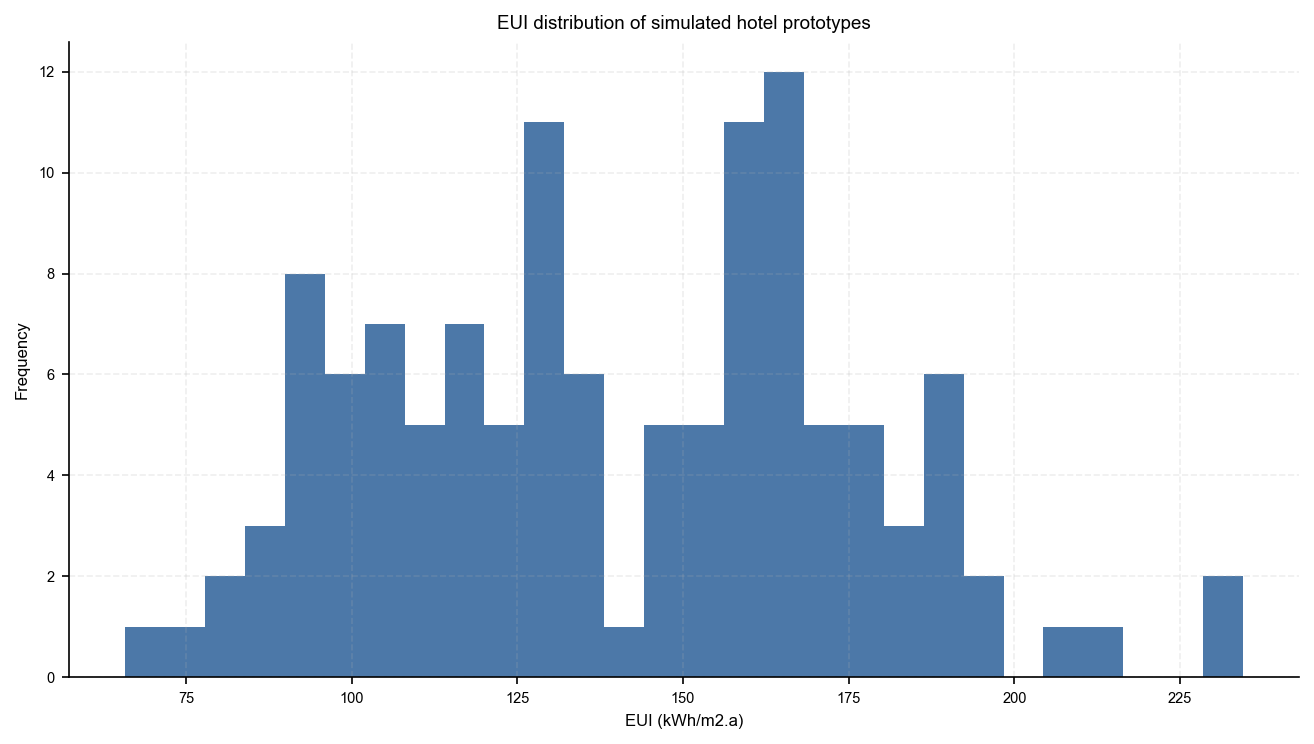

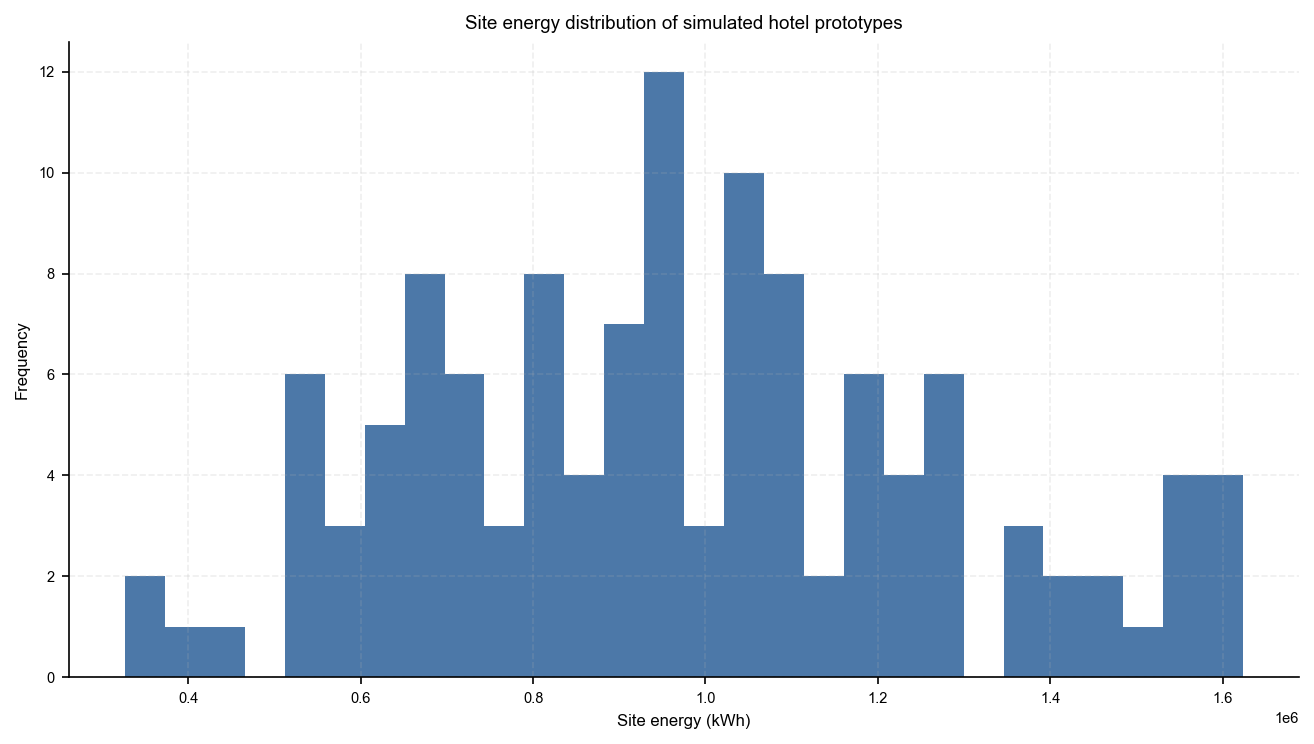

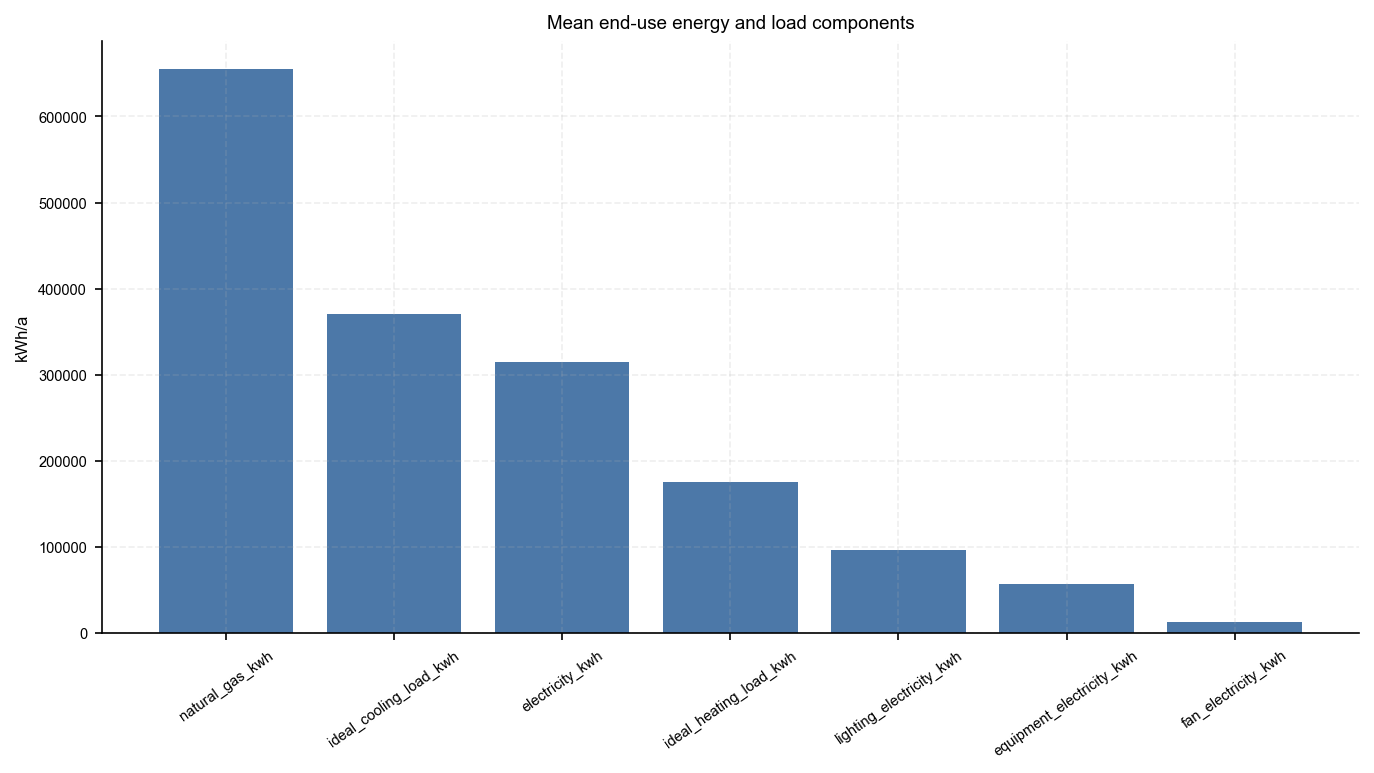

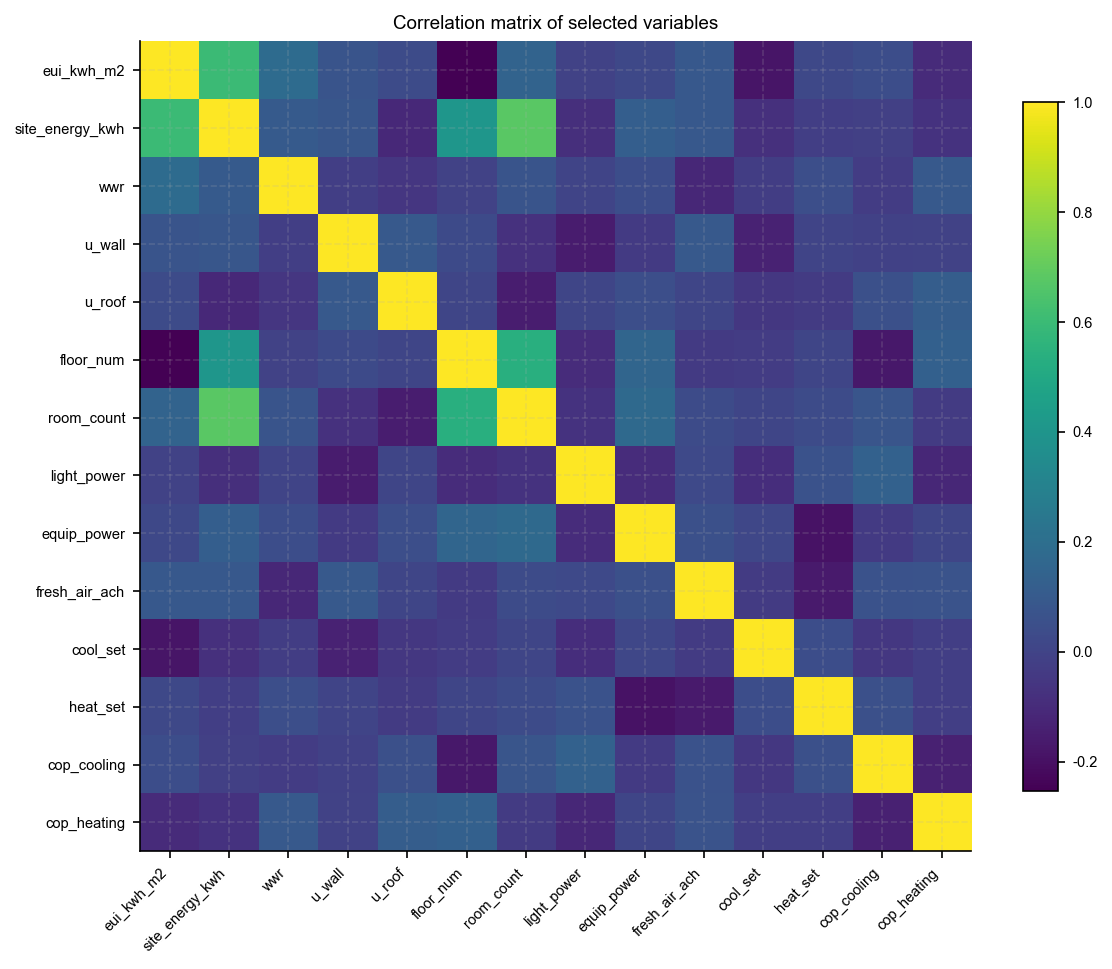

In [11]:
# ---------- 8) Publication-style visualization ----------
dataset_path = DATA_DIR / "step1_simulation_dataset.csv"
if dataset_path.exists():
    df = pd.read_csv(dataset_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    ax.hist(df["eui_kwh_m2"].dropna(), bins=28)
    ax.set_title("EUI distribution of simulated hotel prototypes")
    ax.set_xlabel("EUI (kWh/m2.a)")
    ax.set_ylabel("Frequency")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "eui_distribution.png", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    ax.hist(df["site_energy_kwh"].dropna(), bins=28)
    ax.set_title("Site energy distribution of simulated hotel prototypes")
    ax.set_xlabel("Site energy (kWh)")
    ax.set_ylabel("Frequency")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "site_energy_distribution.png", bbox_inches="tight")
    plt.show()

    plot_cols = [
        "electricity_kwh",
        "natural_gas_kwh",
        "ideal_cooling_load_kwh",
        "ideal_heating_load_kwh",
        "lighting_electricity_kwh",
        "equipment_electricity_kwh",
        "fan_electricity_kwh",
    ]
    
    available = [c for c in plot_cols if c in df.columns]
    mean_vals = df[available].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9.2, 5.2))
    ax.bar(mean_vals.index, mean_vals.values)
    ax.set_title("Mean end-use energy and load components")
    ax.set_ylabel("kWh/a")
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "average_enduses.png", bbox_inches="tight")
    plt.show()

    corr_cols = [c for c in [
        "eui_kwh_m2", "site_energy_kwh", "wwr", "u_wall", "u_roof", "floor_num", "room_count",
        "light_power", "equip_power", "fresh_air_ach", "cool_set", "heat_set", "cop_cooling", "cop_heating"
    ] if c in df.columns]
    corr = df[corr_cols].corr(numeric_only=True)

    fig, ax = plt.subplots(figsize=(8.0, 6.5))
    im = ax.imshow(corr, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title("Correlation matrix of selected variables")
    fig.colorbar(im, ax=ax, shrink=0.85)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "correlation_matrix.png", bbox_inches="tight")
    plt.show()
else:
    print("step1_simulation_dataset.csv has not been generated yet. Please run the simulations first.")

<!-- CODEx Chinese cell explanation: start -->
### Cell 12 — 中文说明（提交前可删除）

**研究目的**：本 cell 执行论文代码包中的一个可复现计算步骤，并为后续分析提供数据、图表或诊断结果。

**输入与依赖**：本 cell 依赖前序 cell 已定义的数据对象、配置参数、文件路径或模型对象；若它是当前 notebook 的第一个代码 cell，则依赖本地 Python/Jupyter 环境和项目目录结构。

**输出与复现作用**：本 cell 生成内存对象、CSV 表格、图像文件、模型文件或诊断打印信息，并作为后续 notebook 步骤和论文修订证据链的一部分。

**审稿意见对应**：对应审稿意见：用于支撑修订版论文的可复现性、方法透明度或结果稳健性。
<!-- CODEx Chinese cell explanation: end -->

<!-- CODEx English cell explanation: start -->
### Cell 12 — Computational step 12

**Research purpose**: This cell executes one reproducible computational step in the manuscript code package and provides data, figures, or diagnostics for downstream analysis.

**Inputs and dependencies**: This cell depends on data objects, configuration values, file paths, or fitted model objects defined in previous cells; if it is the first code cell in the notebook, it depends on the local Python/Jupyter environment and the project directory structure.

**Outputs and reproducibility role**: This cell generates in-memory objects, CSV tables, figure files, model files, or diagnostic printouts that become part of the downstream notebook workflow and the manuscript-revision evidence chain.

**Reviewer-response link**: Reviewer-response link: supports reproducibility, methodological transparency, or result robustness in the revised manuscript.
<!-- CODEx English cell explanation: end -->

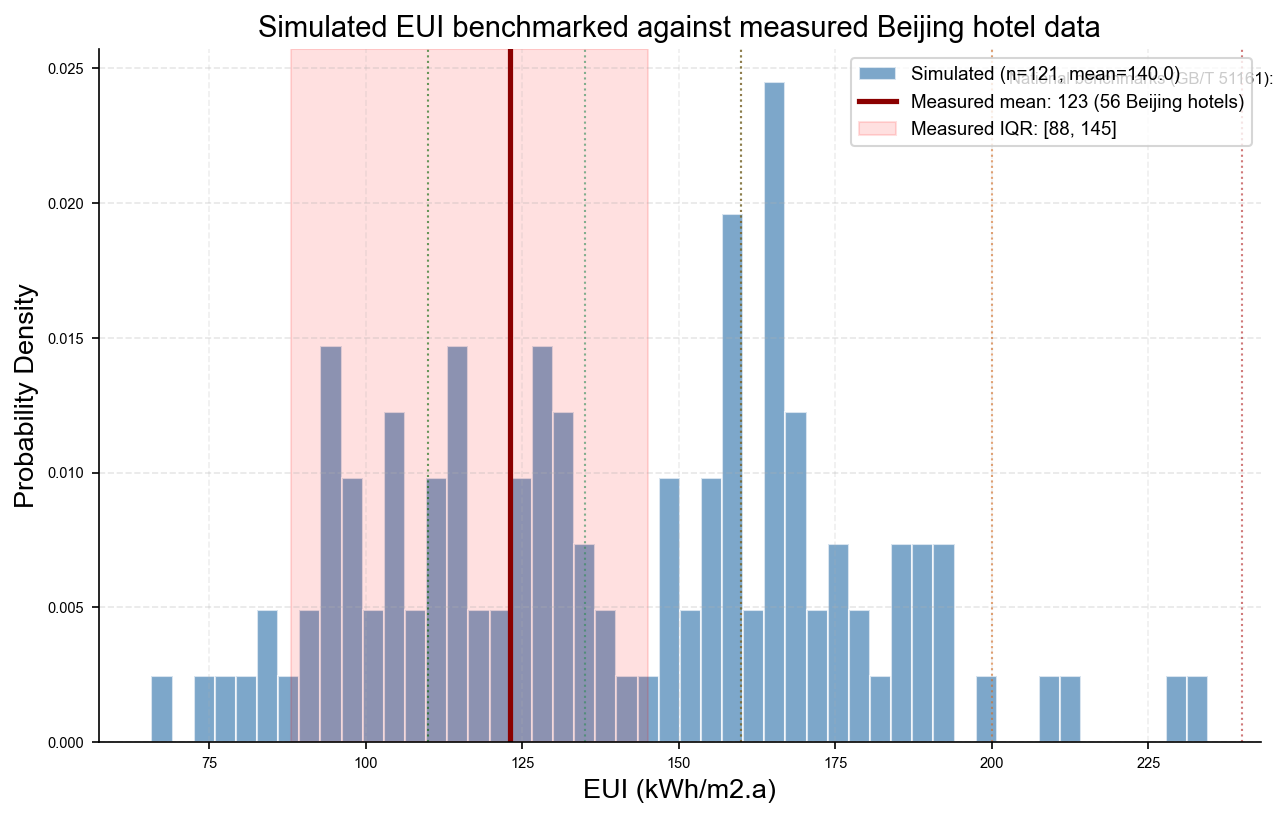

SIM-TO-REAL EUI COMPARISON
Simulated EUI:  mean=140.0, median=137.2, std=35.5, range=[65.8, 234.5]
Measured EUI:   mean=123.0, range=[44.8, 342.5]
Mean difference: 17.0 kWh/m2.a (13.8%)
NOTE: Simulated mean is 13.8% higher than measured mean — see Discussion for sim-to-real gap analysis.


In [12]:
# ============================================================
# [IMPROVEMENT P0-1] Real-Building EUI Benchmark Comparison
# Compare simulated EUI distribution against published Beijing hotel
# measured data to address the sim-to-real transfer gap.
# ============================================================

# Published Beijing hotel EUI benchmarks (Chen, Tan & Berardi, 2018; 56 hotels)
measured_stats = {
    'source': 'Chen, Tan & Berardi (2018) — 56 Beijing hotels',
    'mean': 123.03,   # kWh/m2.a
    'min': 44.76,
    'max': 342.47,
    'std': 45.5,      # estimated from right-skewed distribution
    'q25': 88.0,      # estimated from lognormal fit
    'q50': 110.0,
    'q75': 145.0,
}

# Chinese national benchmark for cold-zone hotels (GB/T 51161-2016)
national_benchmarks = {
    'Cat A 3-star': 110,
    'Cat A 4-star': 135,
    'Cat A 5-star': 160,
    'Cat B 3-star': 160,
    'Cat B 4-star': 200,
    'Cat B 5-star': 240,
}

# Check if simulation data exists (skip if not yet generated)
dataset_path = PROJECT_ROOT / 'data' / 'step1_simulation_dataset.csv'
if not dataset_path.exists():
    print('WARNING: step1_simulation_dataset.csv not found. Simulations have not been run yet.')
    print('Skipping real-building EUI comparison. Run EnergyPlus simulations first (set CONFIG["run_energyplus"] = True).')
else:
    df_eui = pd.read_csv(dataset_path)
    sim_eui = df_eui['eui_kwh_m2'].dropna()

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

    # Simulated distribution
    ax.hist(sim_eui, bins=50, color='steelblue', edgecolor='white', alpha=0.7,
            density=True, label=f'Simulated (n={len(sim_eui):,}, mean={sim_eui.mean():.1f})')

    # Overlay measured range
    ax.axvline(measured_stats['mean'], color='darkred', linestyle='-', linewidth=2.5,
               label=f"Measured mean: {measured_stats['mean']:.0f} (56 Beijing hotels)")
    ax.axvspan(measured_stats['q25'], measured_stats['q75'], alpha=0.12, color='red',
               label=f"Measured IQR: [{measured_stats['q25']:.0f}, {measured_stats['q75']:.0f}]")

    # National benchmarks
    colors = ['darkgreen', 'seagreen', 'forestgreen', 'sienna', 'chocolate', 'firebrick']
    for (label, val), c in zip(national_benchmarks.items(), colors):
        ax.axvline(val, color=c, linestyle=':', linewidth=1, alpha=0.6)
    ax.text(245, ax.get_ylim()[1]*0.95, 'National benchmarks (GB/T 51161):', fontsize=8, ha='right')

    ax.set_xlabel('EUI (kWh/m2.a)', fontsize=13)
    ax.set_ylabel('Probability Density', fontsize=13)
    ax.set_title('Simulated EUI benchmarked against measured Beijing hotel data', fontsize=14)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

    out_dir = PROJECT_ROOT / 'outputs_step1' / 'figures'
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / 'eui_measured_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Quantitative comparison
    print("=" * 50)
    print("SIM-TO-REAL EUI COMPARISON")
    print("=" * 50)
    print(f"Simulated EUI:  mean={sim_eui.mean():.1f}, median={sim_eui.median():.1f}, "
          f"std={sim_eui.std():.1f}, range=[{sim_eui.min():.1f}, {sim_eui.max():.1f}]")
    print(f"Measured EUI:   mean={measured_stats['mean']:.1f}, "
          f"range=[{measured_stats['min']:.1f}, {measured_stats['max']:.1f}]")
    print(f"Mean difference: {sim_eui.mean() - measured_stats['mean']:.1f} kWh/m2.a "
          f"({(sim_eui.mean()/measured_stats['mean'] - 1)*100:.1f}%)")
    print(f"NOTE: Simulated mean is {(sim_eui.mean()/measured_stats['mean'] - 1)*100:.1f}% higher "
          f"than measured mean — see Discussion for sim-to-real gap analysis.")
